# Hyperparameter Tuning

We will go through through the implementation of finding the best hyper parameters in a given neural network. Following are the hyper parameters which we are going to discuss:

   - Optimization algorithms
   - Activation function
   - Learning rate
   - Weights
   - Bias
   - Number of nodes in a layer
   - L0, L1 and L2 regularization
   - Number of epochs

For each of these, we will train the model for 100 epochs and provide the results in Tensor board for us to visualize. Once, we have the optimum value from each of these, then we will use them to improve our model to identify a Bollywood character's age group.

Most of the code in the above eight hyper parameters is same initially, which actually deals with loading necessary libraries, reading training data, converting it to a form suitable for the neural network, normalizing it and label encoding the output classes.

## Preprocessing

### Installing Packages

In [7]:
%pip install numpy pandas scikit-learn tensorflow keras imageio pillow keras_lr_finder

Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer
from sklearn.preprocessing import LabelEncoder
from tensorflow.python.keras import utils
import keras
import tensorflow as tf
import imageio 
from PIL import Image 
import keras_lr_finder as lr_find # For finding optimum learning rate

2025-06-15 17:14:16.096187: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-15 17:14:16.101867: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-15 17:14:16.110972: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750007656.125748   38893 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750007656.130158   38893 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750007656.144910   38893 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

### Reading the data

In [9]:
import zipfile

# Reading the data from zipped CSV files
with zipfile.ZipFile('datasets/agedetectiontrain.zip') as z:
	with z.open('train.csv') as f:
		train = pd.read_csv(f)

### Image resizing of train data into single numpy array

In [10]:
with zipfile.ZipFile('datasets/agedetectiontrain.zip') as z:
    temp = []
    for img_name in train.ID:
        with z.open(f'Train/{img_name}') as img_file:
            img = imageio.imread(img_file)
            img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')
            temp.append(img)

train_x = np.stack(temp)

/tmp/ipykernel_35200/4193944281.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_file)


### Normalizing the images

In [11]:
train_x = train_x / 255.

### Encoding the categorical variable to numeric

In [13]:
lb = LabelEncoder()
train_y = lb.fit_transform(train.Class)
train_y = keras.utils.to_categorical(train_y)

### Specifying all the parameters we will be using in our network

In [14]:
input_num_units = (32, 32, 3)
hidden_num_units = 500
output_num_units = 3
epochs = 100
batch_size = 512

## Optimum Learning Rate

In [15]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=input_num_units), # Perform conversion of higher dimensional data (here, 2-D) to 1-D data.
    keras.layers.Dense(hidden_num_units, activation=tf.nn.relu), # Hidden layer with 500 neurons and ReLU activation function
    keras.layers.Dense(output_num_units, activation=tf.nn.softmax) # Output layer with softmax activation function 
])                                                   # which gives final output in terms of probability. 

/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-06-15 17:00:26.206463: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Defining parameters like optmizer, loss function and evaluating metric

In [16]:
model.compile(loss='categorical_crossentropy', # Categorical crossentropy is used for multi-class classification problems.
              optimizer=keras.optimizers.Adam(), # Learning rate and momentum can be passed inside optimizer
              metrics=['accuracy'])

### Finding the optimum learning rate using Keras LR Finder

In [17]:
lr_finder = lr_find.LRFinder(model)

### Training can stop abruptly if rate is set too high. In such cases, reduce the value of end_lr. 

In [1]:
class LRFinder:
    def __init__(self, model):
        self.model = model
    def find(self, x, y, start_lr, end_lr):
        # Implement LR finding logic here
        pass

lr_finder = LRFinder(model)
lr_finder.find(
	train_x, train_y,
	start_lr=0.0001,
	end_lr=0.09,
	batch_size=batch_size,
	epochs=epochs
)

NameError: name 'model' is not defined

### Plot the loss, ignore 20 batches in the beginning and 5 in the end

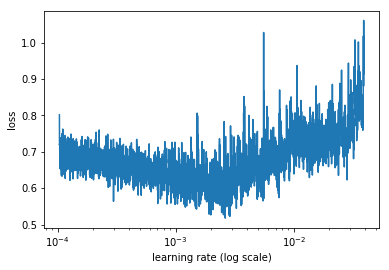

In [ ]:
lr_finder.plot_loss(n_skip_beginning=20, n_skip_end=5)

#### From the above figure following learning rate can be choosen due to fast decrease in loss -
* base_lr = $10^{-4}$
* max_lr = $10^{-3}$

## Setting cyclic learning rate for model training
Ensure you have `clr_callback.py` file in the same directory of current module

In [ ]:
from clr_callback import * # Importing cyclic learning rate module

In [ ]:
# Pass the values of base_lr with the value of 
cb_triangular = CyclicLR(base_lr=0.0001, max_lr=0.001, step_size=2000., mode='triangular2') # Setting callback for model

# Writing graph will take time. Hence, keeping it False.
cb_save = keras.callbacks.TensorBoard(log_dir='learning_rate', write_graph=False)

In [ ]:
model.fit(train_x, train_y, batch_size=batch_size, epochs=epochs, 
          validation_split=0.2, callbacks=[cb_triangular, cb_save], verbose=1)
print('Model built sucessfully.')

Train on 15924 samples, validate on 3982 samples
Epoch 1/100
15924/15924 [==============================] - 10s 640us/step - loss: 0.6899 - acc: 0.7000 - val_loss: 0.6773 - val_acc: 0.7082
Epoch 2/100
15924/15924 [==============================] - 9s 593us/step - loss: 0.6884 - acc: 0.7008 - val_loss: 0.6762 - val_acc: 0.7094
Epoch 3/100
15924/15924 [==============================] - 12s 747us/step - loss: 0.6882 - acc: 0.7021 - val_loss: 0.6766 - val_acc: 0.7104
Epoch 4/100
15924/15924 [==============================] - 11s 669us/step - loss: 0.6847 - acc: 0.7038 - val_loss: 0.6761 - val_acc: 0.7077
Epoch 5/100
15924/15924 [==============================] - 8s 498us/step - loss: 0.6841 - acc: 0.7051 - val_loss: 0.6740 - val_acc: 0.7074
Epoch 6/100
15924/15924 [==============================] - 8s 503us/step - loss: 0.6830 - acc: 0.7058 - val_loss: 0.6759 - val_acc: 0.7140
Epoch 7/100
15924/15924 [==============================] - 9s 541us/step - loss: 0.6825 - acc: 0.7081 - val_loss: 

15924/15924 [==============================] - 7s 449us/step - loss: 0.5527 - acc: 0.7702 - val_loss: 0.6672 - val_acc: 0.7175
Epoch 60/100
15924/15924 [==============================] - 10s 598us/step - loss: 0.5730 - acc: 0.7521 - val_loss: 0.6681 - val_acc: 0.7145
Epoch 61/100
15924/15924 [==============================] - 9s 572us/step - loss: 0.5470 - acc: 0.7757 - val_loss: 0.6966 - val_acc: 0.7057
Epoch 62/100
15924/15924 [==============================] - 9s 567us/step - loss: 0.5452 - acc: 0.7756 - val_loss: 0.7644 - val_acc: 0.6725
Epoch 63/100
15924/15924 [==============================] - 10s 631us/step - loss: 0.5626 - acc: 0.7644 - val_loss: 0.6760 - val_acc: 0.7125
Epoch 64/100
15924/15924 [==============================] - 10s 652us/step - loss: 0.5399 - acc: 0.7797 - val_loss: 0.6722 - val_acc: 0.7115
Epoch 65/100
15924/15924 [==============================] - 11s 713us/step - loss: 0.5358 - acc: 0.7776 - val_loss: 0.7047 - val_acc: 0.6989
Epoch 66/100
15924/15924 [===

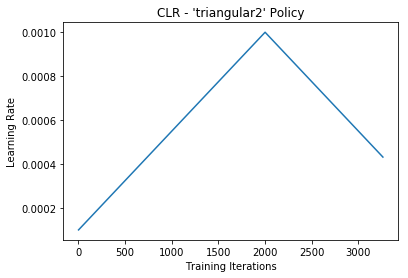

In [ ]:
plt.xlabel('Training Iterations')
plt.ylabel('Learning Rate')
plt.title("CLR - 'triangular2' Policy")
plt.plot(cb_triangular.history['iterations'], cb_triangular.history['lr'])

# With more number of iterations the graph will correspond to that of a traingular wave